### DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING 

#### Objective:
- This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.

#### Dataset:
- Given "Adult" dataset, which predicts whether income exceeds $50K/yr based on census data.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("adult_with_headers (1).csv")

In [3]:
df.head(10)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df.shape

(32561, 15)

- 1.	Handle missing values as per the best practices (imputation, removal, etc.).

In [7]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [8]:
for col in df.select_dtypes(include='object').columns:
    print(col, (df[col].str.strip() == '?').sum())

workclass 1836
education 0
marital_status 0
occupation 1843
relationship 0
race 0
sex 0
native_country 583
income 0


In [9]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df = df.replace('?', np.nan)

In [10]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [11]:
cat_col = df.select_dtypes(include='object').columns
for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [13]:
num_col = df.select_dtypes(include='int64').columns
print("Numeric Col :")
print(num_col)
print("\nCategorical Col :")
print(cat_col)

Numeric Col :
Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

Categorical Col :
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


-	Apply scaling techniques to numerical features:

a.	Standard Scaling   b. Min-Max Scaling


In [14]:
scaler = StandardScaler()
df_standard = df.copy()
df_standard[num_col]= scaler.fit_transform(
    df_standard[num_col]
)
df_standard[num_col].head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [15]:
df_standard[num_col].describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04
mean,-2.705915e-17,-1.001625e-16,1.471887e-16,1.309314e-17,1.016900e-16,-1.549355e-17
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-1.582206e+00,-1.681631e+00,-3.529656e+00,-1.459205e-01,-2.166595e-01,-3.194030e+00
25%,-7.757679e-01,-6.816910e-01,-4.200596e-01,-1.459205e-01,-2.166595e-01,-3.542945e-02
50%,-1.159546e-01,-1.082193e-01,-3.136003e-02,-1.459205e-01,-2.166595e-01,-3.542945e-02
75%,6.904838e-01,4.478765e-01,7.460392e-01,-1.459205e-01,-2.166595e-01,3.695194e-01
max,3.769612e+00,1.226856e+01,2.300838e+00,1.339458e+01,1.059351e+01,4.742967e+00


In [16]:
min_mxs = MinMaxScaler()
df_minx = df.copy()
df_minx[num_col] = min_mxs.fit_transform(
    df_minx[num_col]
)
df_minx[num_col].head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


In [17]:
df_minx[num_col].describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,0.295639,0.120545,0.605379,0.010777,0.020042,0.402423
std,0.186855,0.071685,0.171515,0.073854,0.092507,0.125994
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.071679,0.533333,0.000000,0.000000,0.397959
50%,0.273973,0.112788,0.600000,0.000000,0.000000,0.397959
75%,0.424658,0.152651,0.733333,0.000000,0.000000,0.448980
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


-	Discuss the scenarios where each scaling technique is preferred and why.

#### Standard Scaling
- Standard Scaling transforms numerical features so that they have a mean close to 0 and a standard deviation of 1. It is preferred for algorithms such as Logistic Regression, SVM, KNN and PCA where differences in feature scale can affect model performance. It is less affected by extreme values than Min-Max Scaling, although it can still be influenced by outliers.

#### Min-Max Scaling
- Min-Max Scaling transforms numerical features to a fixed range, usually 0 to 1. It is useful for algorithms such as KNN and neural networks where a bounded feature range can be beneficial. However, it is sensitive to outliers because the minimum and maximum values determine the transformed range.

In [18]:
for col in cat_col:
    print(col, ":", df[col].nunique())

workclass : 8
education : 16
marital_status : 7
occupation : 14
relationship : 6
race : 5
sex : 2
native_country : 41
income : 2


#### 2. Encoding Techniques:
- Apply One-Hot Encoding to categorical variables with less than 5 categories.

In [19]:
one_ht_c = ['sex']
df_encod = pd.get_dummies(
    df,
    columns=one_ht_c,
    drop_first=True
)

In [20]:
df_encod.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_Male
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,<=50K,True
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,<=50K,True
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,<=50K,True
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,<=50K,True
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,<=50K,False


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


- Use Label Encoding for categorical variables. Data Exploration and Preprocessing:
- Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).
- less with more than 5 categories.

In [22]:
enc_col = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'native_country'
]

for col in enc_col:
    lb = LabelEncoder()
    df[col + '_enc'] = lb.fit_transform(df[col])

In [23]:
df[['workclass', 'workclass_enc']].head(10)

,workclass,workclass_enc
0,State-gov,6
1,Self-emp-not-inc,5
2,Private,3
3,Private,3
4,Private,3
5,Private,3
6,Private,3
7,Self-emp-not-inc,5
8,Private,3
9,Private,3


In [24]:
df[['marital_status', 'marital_status_enc']].head(10)

,marital_status,marital_status_enc
0,Never-married,4
1,Married-civ-spouse,2
2,Divorced,0
3,Married-civ-spouse,2
4,Married-civ-spouse,2
5,Married-civ-spouse,2
6,Married-spouse-absent,3
7,Married-civ-spouse,2
8,Never-married,4
9,Married-civ-spouse,2


- Discuss the pros and cons of One-Hot Encoding and Label Encoding.

#### One-Hot Encoding – Pros and Cons
- One-Hot Encoding is a technique that converts categorical values into separate binary columns containing 0s and 1s. One of its main advantages is that it does not create any artificial relationship or ranking between categories. This makes it suitable for variables such as sex, where categories like Male and Female do not have any numerical order. However, its main disadvantage is that when a categorical variable has many unique categories, it can create a large number of new columns. This increases the size and complexity of the dataset and can also increase memory usage.

#### Label Encoding – Pros and Cons

- Label Encoding converts each category into a numerical value, such as assigning 0, 1, 2, and so on to different categories. Its main advantage is that it represents a categorical variable using only one column, so it is simple and does not significantly increase the size of the dataset. This makes it useful when a variable contains many categories. However, the main disadvantage is that the assigned numbers can create an artificial sense of order between categories. For example, if Private is represented by 3 and State-gov by 6, it may appear that State-gov is greater than Private even though there is no such relationship. Therefore, Label Encoding should be used carefully, especially with algorithms that interpret numerical values as having an order or distance.

#### 3. Feature Engineering:
- Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.

In [25]:
df['age_grp'] = pd.cut(
    df['age'],
    bins = [16,25,35,50,65,100],
    labels = ['Young','Early_Adult','Middle_Age','Senior','Elderly']
)

In [26]:
df[['age', 'age_grp']].head(30)

,age,age_grp
0,39,Middle_Age
1,50,Middle_Age
2,38,Middle_Age
3,53,Senior
4,28,Early_Adult
5,37,Middle_Age
6,49,Middle_Age
7,52,Senior
8,31,Early_Adult
9,42,Middle_Age


In [27]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income', 'workclass_enc', 'education_enc', 'marital_status_enc',
       'occupation_enc', 'relationship_enc', 'native_country_enc', 'age_grp'],
      dtype='object')

In [28]:
df['net_capital'] = df['capital_gain'] - df['capital_loss']
df[['capital_gain', 'capital_loss', 'net_capital']].head(30)

,capital_gain,capital_loss,net_capital
0,2174,0,2174
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,14084,0,14084
9,5178,0,5178


In [29]:
df['hours_category'] = pd.cut(
    df['hours_per_week'],
    bins = [0,20,40,60,100],
    labels=['Part-time','Full-time','Overtime','Very_High']
)

In [30]:
df[['hours_category','hours_per_week']].head(10)

,hours_category,hours_per_week
0,Full-time,40
1,Part-time,13
2,Full-time,40
3,Full-time,40
4,Full-time,40
5,Full-time,40
6,Part-time,16
7,Overtime,45
8,Overtime,50
9,Full-time,40


In [31]:
df[num_col].skew().sort_values(ascending=False)

capital_gain      11.953848
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
hours_per_week     0.227643
education_num     -0.311676
dtype: float64

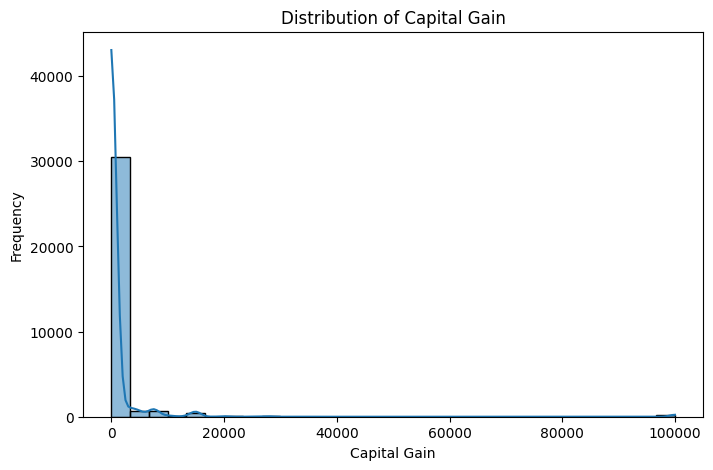

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df['capital_gain'], bins=30, kde=True)
plt.title('Distribution of Capital Gain')
plt.xlabel('Capital Gain')
plt.ylabel('Frequency')
plt.show()

- Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.

In [33]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

In [34]:
df[['capital_gain', 'capital_gain_log']].head(10)

,capital_gain,capital_gain_log
0,2174,7.684784
1,0,0.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000
5,0,0.000000
6,0,0.000000
7,0,0.000000
8,14084,9.552866
9,5178,8.552367


In [35]:
print("Original skewness:",
      df['capital_gain'].skew())

print("Log-transformed skewness:",
      df['capital_gain_log'].skew())

Original skewness: 11.953847687699799
Log-transformed skewness: 3.096143524467517


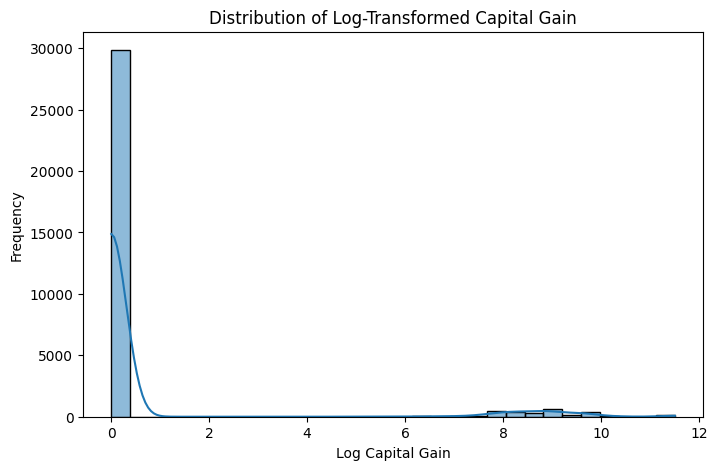

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(df['capital_gain_log'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed Capital Gain')
plt.xlabel('Log Capital Gain')
plt.ylabel('Frequency')
plt.show()

- The capital_gain feature was selected for log transformation because it was highly right-skewed, with a skewness of approximately 11.95. Most observations had a capital gain of zero, while a small number of observations had extremely large values, with a maximum of 99,999. This large difference between the majority of observations and extreme values can negatively influence some machine learning models. Therefore, np.log1p() was applied to reduce the effect of extreme values and make the distribution less skewed. log1p() was used instead of a normal log transformation because the feature contains many zero values.